### Importación de datos



In [2]:
from math import trunc
import matplotlib.pyplot as plt
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)
tienda.head()


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


# 1. Análisis de facturación





In [3]:
ingresos = {
    "Tienda 1": tienda["Precio"].sum(),
    "Tienda 2": tienda2["Precio"].sum(),
    "Tienda 3": tienda3["Precio"].sum(),
    "Tienda 4": tienda4["Precio"].sum()
}

     Tienda  Ingreso Total  Ingreso (Millones)
0  Tienda 1  1150880400.00             1150.88
1  Tienda 2  1116343500.00             1116.34
2  Tienda 3  1098019600.00             1098.02
3  Tienda 4  1038375700.00             1038.38


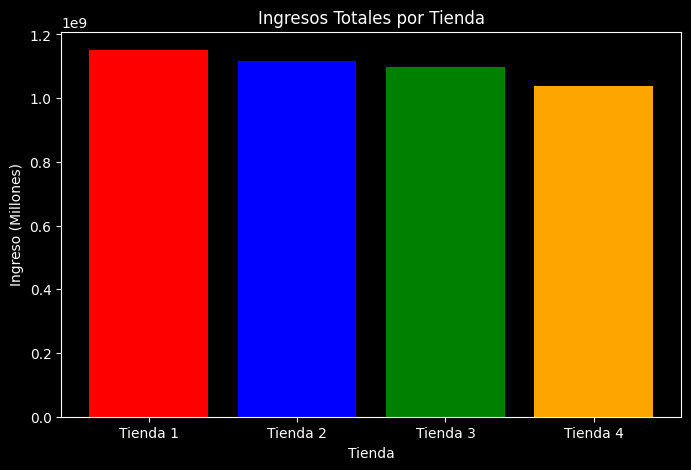

In [16]:
# Convertir a DataFrame
df_ingresos = pd.DataFrame(
    ingresos.items(),
    columns=["Tienda", "Ingreso Total"]
)
df_ingresos["Ingreso (Millones)"] = df_ingresos["Ingreso Total"] / 1_000_000
print(df_ingresos)
colores = ["red", "blue", "green", "orange"]

plt.figure(figsize=(8,5))
plt.bar(df_ingresos["Tienda"],
        df_ingresos["Ingreso Total"],
        color=colores)

plt.title("Ingresos Totales por Tienda")
plt.xlabel("Tienda")
plt.ylabel("Ingreso (Millones)")
plt.show()

# 2. Ventas por categoría

In [5]:
prod_cat1 = tienda.groupby("Categoría del Producto").size().sort_values(ascending=False)
prod_cat2 = tienda2.groupby("Categoría del Producto").size().sort_values(ascending=False)
prod_cat3 = tienda3.groupby("Categoría del Producto").size().sort_values(ascending=False)
prod_cat4 = tienda4.groupby("Categoría del Producto").size().sort_values(ascending=False)

In [6]:
print("TIENDA 1",prod_cat1)
print("TIENDA 2",prod_cat2)
print("TIENDA 3",prod_cat3)
print("TIENDA 4",prod_cat4)

TIENDA 1 Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
dtype: int64
TIENDA 2 Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
dtype: int64
TIENDA 3 Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Artículos para el hogar    177
Instrumentos musicales     177
dtype: int64
TIENDA 4 Categoría del Producto
Muebles                    480
Electrónicos               451
Juguetes                   

# 3. Calificación promedio de la tienda


In [7]:
pd.options.display.float_format = '{:.2f}'.format
calificaciones = {
    "Tienda 1": tienda['Calificación'].mean(),
    "Tienda 2": tienda2['Calificación'].mean(),
    "Tienda 3": tienda3['Calificación'].mean(),
    "Tienda 4": tienda4['Calificación'].mean()
}

In [8]:
df_calif = pd.DataFrame(
    calificaciones.items(),
    columns=["Tienda", "Calificacion Promedio"]
)
print(df_calif)

     Tienda  Calificacion Promedio
0  Tienda 1                   3.98
1  Tienda 2                   4.04
2  Tienda 3                   4.05
3  Tienda 4                   4.00


# 4. Productos más y menos vendidos

In [9]:
productovendidos= tienda.groupby('Producto').size().sort_values(ascending=False)
producto_masvendidos= productovendidos.head(3)
producto_menosvendidos= productovendidos.tail(3)
##############################################################################
productovendidos2 = tienda2.groupby('Producto').size().sort_values(ascending=False)
producto_masvendidos2= productovendidos2.head(3)
producto_menosvendidos2= productovendidos2.tail(3)
##############################################################################
productovendidos3 = tienda3.groupby('Producto').size().sort_values(ascending=False)
producto_masvendidos3= productovendidos3.head(3)
producto_menosvendidos3= productovendidos3.tail(3)
##############################################################################
productovendidos4 = tienda4.groupby('Producto').size().sort_values(ascending=False)
producto_masvendidos4= productovendidos4.head(3)
producto_menosvendidos4= productovendidos4.tail(3)
##############################################################################

In [10]:
print("TIENDA 1 MAS VENDIDOS",producto_masvendidos)
print("TIENDA 1 MENOS VENDIDOS",producto_menosvendidos)
print("----------------------------------------------")
print("TIENDA 2 MAS VENDIDOS",producto_masvendidos2)
print("TIENDA 2 MENOS VENDIDOS",producto_menosvendidos2)
print("----------------------------------------------")
print("TIENDA 3 MAS VENDIDOS",producto_masvendidos3)
print("TIENDA 3 MENOS VENDIDOS",producto_menosvendidos3)
print("----------------------------------------------")
print("TIENDA 4 MAS VENDIDOS",producto_masvendidos4)
print("TIENDA 4 MENOS VENDIDOS",producto_menosvendidos4)




TIENDA 1 MAS VENDIDOS Producto
Armario          60
TV LED UHD 4K    60
Microondas       60
dtype: int64
TIENDA 1 MENOS VENDIDOS Producto
Olla de presión              35
Celular ABXY                 33
Auriculares con micrófono    33
dtype: int64
----------------------------------------------
TIENDA 2 MAS VENDIDOS Producto
Iniciando en programación    65
Microondas                   62
Batería                      61
dtype: int64
TIENDA 2 MENOS VENDIDOS Producto
Impresora          34
Mesa de comedor    34
Juego de mesa      32
dtype: int64
----------------------------------------------
TIENDA 3 MAS VENDIDOS Producto
Kit de bancas      57
Mesa de comedor    56
Cama king          56
dtype: int64
TIENDA 3 MENOS VENDIDOS Producto
Microondas                 36
Set de vasos               36
Bloques de construcción    35
dtype: int64
----------------------------------------------
TIENDA 4 MAS VENDIDOS Producto
Cama box      62
Cubertería    59
Cama king     56
dtype: int64
TIENDA 4 MENOS VENDI

# 5. Envío promedio por tienda

In [11]:
envio = {
    "Tienda 1": tienda["Costo de envío"].mean(),
    "Tienda 2": tienda2["Costo de envío"].mean(),
    "Tienda 3": tienda3["Costo de envío"].mean(),
    "Tienda 4": tienda4["Costo de envío"].mean()
}

     Tienda  Envio Promedio
0  Tienda 1        26018.61
1  Tienda 2        25216.24
2  Tienda 3        24805.68
3  Tienda 4        23459.46


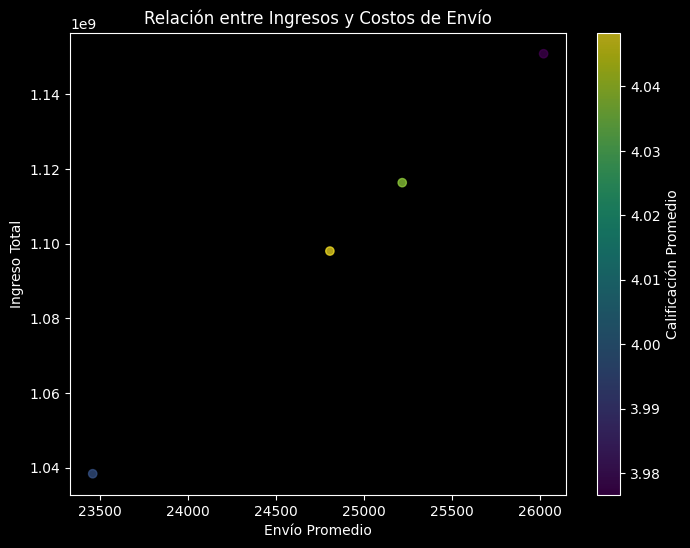

In [12]:
df_envios = pd.DataFrame(
    envio.items(),
    columns=["Tienda", "Envio Promedio"]
)
print(df_envios)
plt.figure(figsize=(8,6))

plt.scatter(
    df_envios["Envio Promedio"],
    df_ingresos["Ingreso Total"],
    c=df_calif["Calificacion Promedio"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Envío Promedio")
plt.ylabel("Ingreso Total")
plt.title("Relación entre Ingresos y Costos de Envío")

plt.colorbar(label="Calificación Promedio")
plt.show()


# 6. Ingreso promedio por venta (ticket promedio

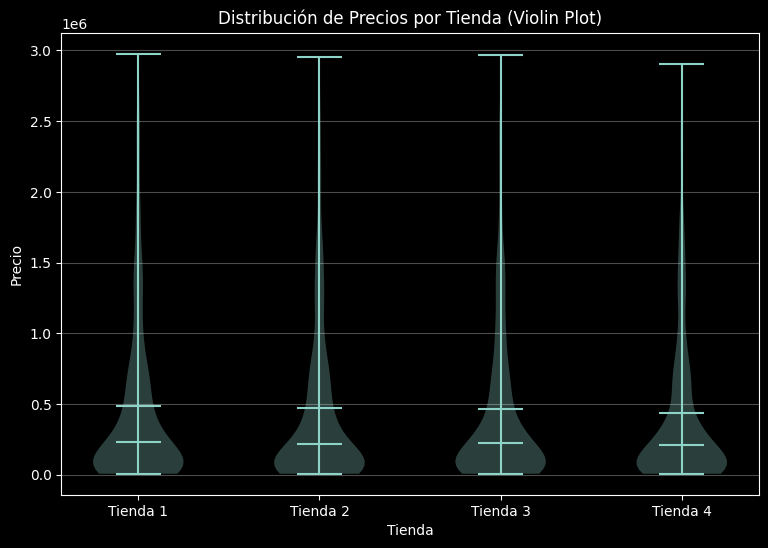

In [15]:
# 6. Boxplot de precios por tienda (tipo de gráfico nuevo)

datos_precios = [
    tienda["Precio"],
    tienda2["Precio"],
    tienda3["Precio"],
    tienda4["Precio"]
]

plt.figure(figsize=(9,6))

plt.violinplot(
    datos_precios,
    showmeans=True,
    showmedians=True
)

plt.xticks(
    [1, 2, 3, 4],
    ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]
)

plt.title("Distribución de Precios por Tienda (Violin Plot)")
plt.xlabel("Tienda")
plt.ylabel("Precio")
plt.grid(axis="y", alpha=0.3)
plt.show()